<span style="color: #ead5d0; font-size: 28px; font-weight: bold;">
    NOW WE HOP ON TO CALCULATING AND ANALYZING THE DATA 
CALCULATE THE MEAN AND MEDIAN AND THE MODE 
</span>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df= pd.read_excel("d:\\decodelab project\\cleaned_dataset_for_DataAnalytics.xlsx")

In [5]:

print(df.shape)           
print(df.columns)         
print(df.head())        
print(df.info())          
print(df.describe())      

(1200, 18)
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'Is_Coupons', 'Month', 'Year', 'check_totalprice'],
      dtype='object')
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK4290

In [ ]:
Average_totalprice=np.mean(df['TotalPrice'])
Sum_totalprice=np.sum(df['TotalPrice'])
average_unitprice=np.mean(df['UnitPrice'])
sum_unitprice=np.sum(df['UnitPrice'])
average_quantity=np.mean(df['Quantity'])
sum_quantity=np.sum(df['Quantity'])
highest_product=df['Product'].mode()[0]
measures={
    'Average Total Price': Average_totalprice,

        'Total Revenue': Sum_totalprice,

        'Average Unit Price': average_unitprice,

        'Total Unit Price': sum_unitprice,

        'Average Quantity': average_quantity,

        'Total Quantity': sum_quantity,
        
        'Most Purchased Product': highest_product
}
print(measures)
plt.figure(figsize=(10, 6))

{'Average Total Price': np.float64(1053.9683), 'Sum Total Price': np.float64(1264761.96), 'Average Unit Price': np.float64(356.41275), 'Sum Unit Price': np.float64(427695.3), 'Average Quantity': np.float64(2.9458333333333333), 'Sum Quantity': np.int64(3535), 'Most Purchased Product': 'Printer'}


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Correlation Matrix:
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity        1.000      0.015       0.615        0.650
UnitPrice       0.015      1.000       0.717        0.001
TotalPrice      0.615      0.717       1.000        0.393
ItemsInCart     0.650      0.001       0.393        1.000


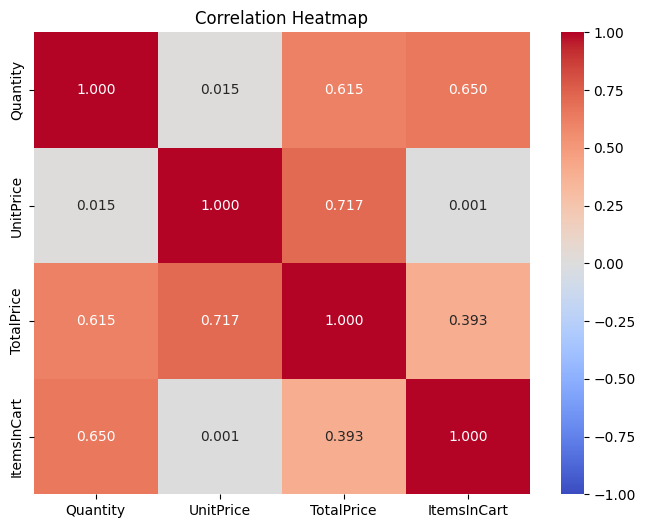


Top Correlations with TotalPrice:
TotalPrice     1.000
UnitPrice      0.717
Quantity       0.615
ItemsInCart    0.393
Name: TotalPrice, dtype: float64


In [6]:
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

corr_matrix = df[numerical_cols].corr(method='pearson')   # You can also use 'spearman'

print("Correlation Matrix:")
print(corr_matrix.round(3))
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()

print("\nTop Correlations with TotalPrice:")
print(corr_matrix['TotalPrice'].sort_values(ascending=False).round(3))

In [11]:
sales_by_month=df.groupby('Month')['TotalPrice'].sum().reset_index()
print(sales_by_month)


        Month  TotalPrice
0       April   109186.05
1      August    86343.21
2    December    82540.50
3    February   112344.78
4     January   124313.23
5        July    85784.64
6        June   170616.13
7       March   123840.93
8         May   135142.59
9    November    75493.43
10    October    89834.82
11  September    69321.65


In [13]:
sales_by_year=df.groupby('Year')['TotalPrice'].sum().reset_index()
print(sales_by_year)

   Year  TotalPrice
0  2023   552643.24
1  2024   480235.87
2  2025   231882.85


ValueError: Could not interpret value `is_coupon` for `x`. An entry with this name does not appear in `data`.

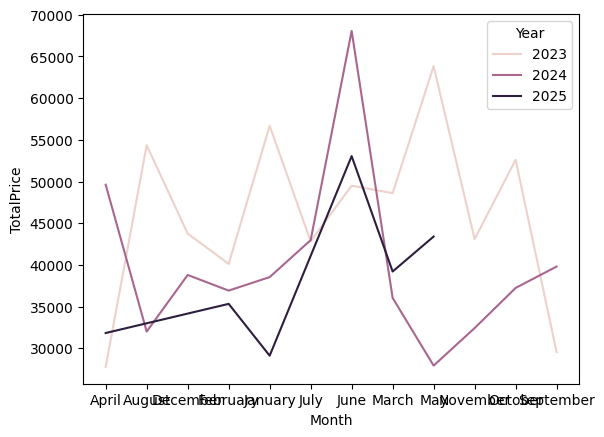

In [18]:
monthly_sales = df.groupby(['Year','Month'])['TotalPrice'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='Month', y='TotalPrice', hue='Year')
sns.barplot(x='is_coupon', y='TotalPrice', data=df)
df['Product'].value_counts().head(10).plot(kind='bar')